<a href="https://colab.research.google.com/github/winston-k/Wi20260413/blob/main/py1444h.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# In[1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # For enhanced visualizations
import os

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# In[2]:
# b. Read the student dataset from CSV
# Try to read the existing CSV file
try:
    # Read the data from CSV file
    df = pd.read_csv('/content/sample_data/student_data.csv')
    print("Successfully loaded data from student_data.csv")

except FileNotFoundError:
    print("CSV file not found. Creating a sample dataset and saving it...")
    # Create a sample dataset if the file is not found
    data = {
        'student_id': range(1001, 1021),
        'name': [f'Student_{i}' for i in range(1, 21)],
        'age': np.random.randint(18, 25, 20),
        'course': np.random.choice(['Math', 'Science', 'History', 'Art'], 20),
        'score': np.random.randint(50, 100, 20)
    }
    df = pd.DataFrame(data)
    df.loc[::5, 'score'] = np.nan # Introduce some missing scores
    df.loc[1, 'age'] = np.nan # Introduce a missing age
    df.to_csv('/content/sample_data/student_data.csv', index=False)
    print("Sample dataset created and saved to student_data.csv")

# Display the first few rows of the dataset
print("\nFirst 5 rows of the student dataset:")
print(df.head())

# Display basic information about the dataset
print("\nDataset information:")
print(df.info())

# Display summary statistics
print("\nSummary statistics:")
print(df.describe())

CSV file not found. Creating a sample dataset and saving it...
Sample dataset created and saved to student_data.csv

First 5 rows of the student dataset:
   student_id       name   age   course  score
0        1001  Student_1  23.0      Art    NaN
1        1002  Student_2   NaN     Math   61.0
2        1003  Student_3  22.0  Science   67.0
3        1004  Student_4  21.0  History   82.0
4        1005  Student_5  19.0  Science   60.0

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   student_id  20 non-null     int64  
 1   name        20 non-null     object 
 2   age         19 non-null     float64
 3   course      20 non-null     object 
 4   score       16 non-null     float64
dtypes: float64(2), int64(1), object(2)
memory usage: 932.0+ bytes
None

Summary statistics:
       student_id        age     score
count    20.00000  19

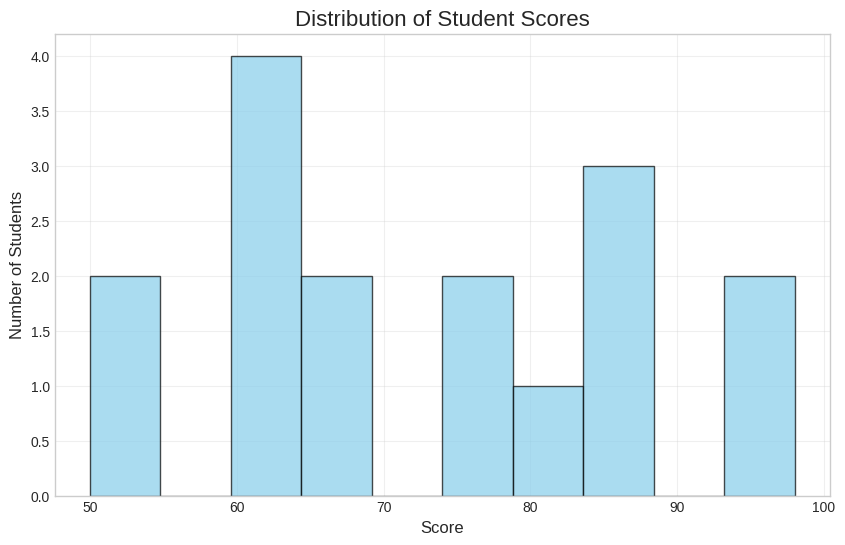

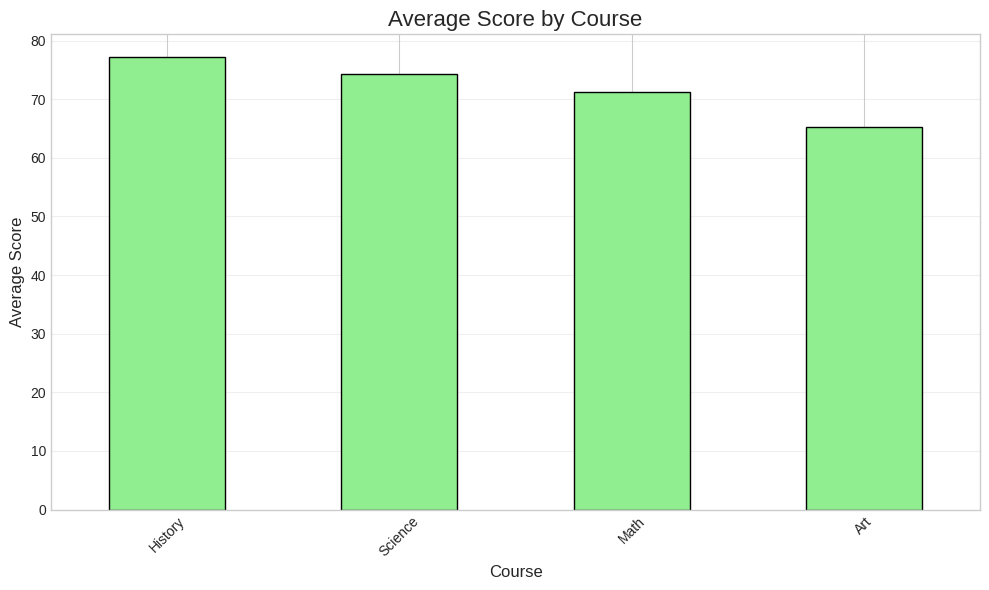

DataFrame with grade categories:
   student_id        name  score grade_category
0        1001   Student_1    NaN       No Score
1        1002   Student_2   61.0  Below Average
2        1003   Student_3   67.0  Below Average
3        1004   Student_4   82.0           Good
4        1005   Student_5   60.0  Below Average
5        1006   Student_6    NaN       No Score
6        1007   Student_7   62.0  Below Average
7        1008   Student_8   60.0  Below Average
8        1009   Student_9   96.0      Excellent
9        1010  Student_10   76.0        Average
Number of students with scores above 80: 6

High performing students:
    student_id        name   course  score grade_category
3         1004   Student_4  History   82.0           Good
8         1009   Student_9  Science   96.0      Excellent
12        1013  Student_13     Math   85.0           Good
17        1018  Student_18      Art   84.0           Good
18        1019  Student_19  History   98.0      Excellent
Missing values in eac

In [ ]:
# 2. Data Manipulation and Enhancement (3 points)
# a. Generate at least two visualizations of the data
# In[3]:

# Visualization 1: Histogram of Student Scores
plt.figure(figsize=(10, 6))
plt.hist(df['score'].dropna(), bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Student Scores', fontsize=16)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualization 2: Average Score by Course
plt.figure(figsize=(10, 6))
avg_by_course = df.groupby('course')['score'].mean().sort_values(ascending=False)
avg_by_course.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Average Score by Course', fontsize=16)
plt.xlabel('Course', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('avg_score_by_course.png', dpi=300, bbox_inches='tight')
plt.show()

# b. Create a new column that categorizes students based on their scores
def categorize_score(score):
    """Categorize scores into grade categories."""
    if pd.isna(score):
        return 'No Score'
    elif score >= 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Below Average'

# Apply the function to create a new column
df['grade_category'] = df['score'].apply(categorize_score)

# Display the DataFrame with the new column
print("DataFrame with grade categories:")
print(df[['student_id', 'name', 'score', 'grade_category']].head(10))

# c. Filter the data to show only students with scores above 80
high_performers = df[df['score'] > 80].copy()
print(f"Number of students with scores above 80: {len(high_performers)}")
print("\nHigh performing students:")
print(high_performers[['student_id', 'name', 'course', 'score', 'grade_category']].head())

# d. Check for and handle any missing values in the dataset
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Count missing scores
missing_scores_count = df['score'].isnull().sum()
print(f"\nNumber of students with missing scores: {missing_scores_count}")

# Handle missing values using mean imputation
mean_score = df['score'].mean()
print(f"Mean score (for imputation): {mean_score:.2f}")

# Create a new column with filled scores
df['score_filled'] = df['score'].fillna(mean_score)

# Create grade category based on filled scores
df['grade_category_filled'] = df['score_filled'].apply(categorize_score)

# Verify no missing values in the new column
print("\nMissing values after imputation:")
print(df[['score', 'score_filled']].isnull().sum())

# Display some examples of rows with imputed values
missing_score_examples = df[df['score'].isnull()].head()
print("\nExamples of rows with imputed scores:")
print(missing_score_examples[['student_id', 'name', 'score', 'score_filled', 'grade_category_filled']])

# e. Create a function to calculate the average score for each course
def get_course_averages(dataframe, score_column='score'):
    """
    Calculate the average score for each course.

    Parameters:
    -----------
    dataframe : pandas.DataFrame
        The student dataframe
    score_column : str, optional
        The name of the score column to use (default: 'score')

    Returns:
    --------
    pandas.DataFrame
        DataFrame with course names and their average scores
    """
    # Group by course and calculate mean score
    averages = dataframe.groupby('course')[score_column].mean().reset_index()

    # Rename columns for clarity
    averages.columns = ['Course', 'Average Score']

    # Sort by average score in descending order
    averages = averages.sort_values('Average Score', ascending=False)

    return averages

# Calculate averages for both original and filled scores
course_avg_original = get_course_averages(df)
course_avg_filled = get_course_averages(df, 'score_filled')

print("Course averages (with missing values):")
print(course_avg_original)

print("\nCourse averages (after handling missing values):")
print(course_avg_filled)

# f. Display summary statistics of the data
# Basic summary statistics by course
summary_by_course = df.groupby('course')['score_filled'].agg(['count', 'mean', 'std', 'min', 'max'])
summary_by_course = summary_by_course.rename(columns={
    'count': 'Number of Students',
    'mean': 'Average Score',
    'std': 'Standard Deviation',
    'min': 'Minimum Score',
    'max': 'Maximum Score'
})

print("Summary Statistics by Course:")
print(summary_by_course)

# Grade distribution
grade_counts = df['grade_category_filled'].value_counts()
grade_percentages = df['grade_category_filled'].value_counts(normalize=True) * 100

print("\nGrade Distribution:")
for grade in ['Excellent', 'Good', 'Average', 'Below Average']:
    if grade in grade_counts:
        count = grade_counts[grade]
        percentage = grade_percentages[grade]
        print(f"{grade}: {count} students ({percentage:.1f}%)")

# Average age by course
avg_age_by_course = df.groupby('course')['age'].mean().sort_values()
print("\nAverage Age by Course:")
print(avg_age_by_course)



In [ ]:
# 4. Control Structures Implementation (4.5 points)
# a. Implement conditional statements to process student data (1.5 points)
print("\n--- Student Performance Analysis ---")
for i, row in df.head().iterrows():
    # Check if score is missing
    if pd.isna(row['score']):
        print(f"{row['name']} has no score recorded.")
        continue

    # Analyze performance based on score
    if row['score'] >= 90:
        performance = "excellent"
        action = "eligible for honors program"
    elif row['score'] >= 80:
        performance = "good"
        action = "on track"
    elif row['score'] >= 70:
        performance = "average"
        action = "could benefit from additional practice"
    else:
        performance = "below average"
        action = "needs tutoring support"

    # Print the analysis
    print(f"{row['name']} in {row['course']} has {performance} performance and is {action}.")


# b. Use loops to iterate through the dataset and perform operations (1.5 points)
print("\n--- Course Statistics Using Loops ---")
course_stats = {}

# For loop to calculate statistics by course
for course_name in df['course'].unique():
    course_data = df[df['course'] == course_name]

    # Calculate stats manually using loops
    total_score = 0
    count = 0
    max_score = 0
    min_score = 100

    for score in course_data['score_filled']:
        total_score += score
        count += 1

        if score > max_score:
            max_score = score
        if score < min_score:
            min_score = score

    # Store the calculated statistics
    course_stats[course_name] = {
        'count': count,
        'avg_score': total_score / count,
        'max_score': max_score,
        'min_score': min_score
    }

# While loop to display statistics
i = 0
courses = list(course_stats.keys())
while i < len(courses):
    course = courses[i]
    stats = course_stats[course]

    print(f"Course: {course}")
    print(f"  Students: {stats['count']}")
    print(f"  Average Score: {stats['avg_score']:.2f}")
    print(f"  Score Range: {stats['min_score']} - {stats['max_score']}")
    print()

    i += 1


# c. Implement exception handling for potential errors (1.5 points)
print("\n--- Exception Handling Examples ---")

# Example 1: Handle missing values when calculating ratios
print("Calculating pass ratios with error handling:")
try:
    for course in df['course'].unique():
        course_df = df[df['course'] == course]
        try:
            # Count passing students (score >= 70)
            passing = sum(score >= 70 for score in course_df['score_filled'])
            total = len(course_df)

            # This will cause division by zero if total is 0
            pass_ratio = passing / total
            print(f"{course}: {pass_ratio:.1%} passing rate ({passing}/{total})")

        except ZeroDivisionError:
            print(f"{course}: No students enrolled")
        except Exception as e:
            print(f"{course}: Error calculating pass ratio - {e}")

except Exception as e:
    print(f"Unexpected error: {e}")

# Example 2: Handle errors when accessing student records
print("\nAccessing student records safely:")
student_ids_to_find = [1001, 9999, "ABC"]

for student_id in student_ids_to_find:
    try:
        print(f"Looking for student ID: {student_id}")

        # Type checking
        if not isinstance(student_id, (int, np.integer)):
            raise TypeError("Student ID must be an integer")

        # Find student by ID
        student = df[df['student_id'] == student_id]

        # Check if student exists
        if len(student) == 0:
            raise ValueError(f"No student found with ID {student_id}")

        # Access student information
        name = student.iloc[0]['name']
        score = student.iloc[0]['score_filled']

        print(f"Found: {name} with score {score:.1f}")

    except TypeError as e:
        print(f"Type error: {e}")
    except ValueError as e:
        print(f"Value error: {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")




--- Student Performance Analysis ---
Student_1 has no score recorded.
Student_2 in Math has below average performance and is needs tutoring support.
Student_3 in Science has below average performance and is needs tutoring support.
Student_4 in History has good performance and is on track.
Student_5 in Science has below average performance and is needs tutoring support.

--- Course Statistics Using Loops ---
Course: Art
  Students: 4
  Average Score: 67.14
  Score Range: 50.0 - 84.0

Course: Math
  Students: 7
  Average Score: 71.59
  Score Range: 60.0 - 85.0

Course: Science
  Students: 3
  Average Score: 74.33
  Score Range: 60.0 - 96.0

Course: History
  Students: 6
  Average Score: 76.43
  Score Range: 52.0 - 98.0


--- Exception Handling Examples ---
Calculating pass ratios with error handling:
Art: 50.0% passing rate (2/4)
Math: 71.4% passing rate (5/7)
Science: 33.3% passing rate (1/3)
History: 66.7% passing rate (4/6)

Accessing student records safely:
Looking for student ID: 1


--- Advanced Data Analysis by Course ---
Grade distribution by course (%):
grade_category_filled  Average  Below Average  Excellent  Good
course                                                        
Art                       25.0           50.0        0.0  25.0
History                   16.7           33.3       16.7  33.3
Math                      57.1           28.6        0.0  14.3
Science                    0.0           66.7       33.3   0.0

Score analysis by course and age group:
                  student_id score_filled            
                       count         mean   min   max
course  age_group                                    
Art     18-20              1         50.0  50.0  50.0
        21-25              3         72.9  62.0  84.0
        26-30              0          NaN   NaN   NaN
        31-35              0          NaN   NaN   NaN
History 18-20              3         70.5  52.0  87.0
        21-25              3         82.3  67.0  98.0
        26-30      

/tmp/ipykernel_7467/2804528128.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_course_analysis = df.groupby(['course', 'age_group']).agg({


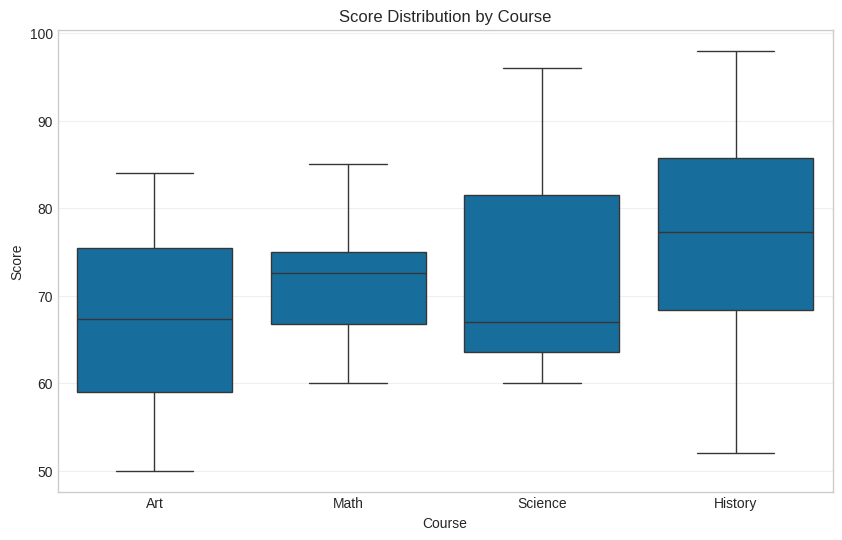

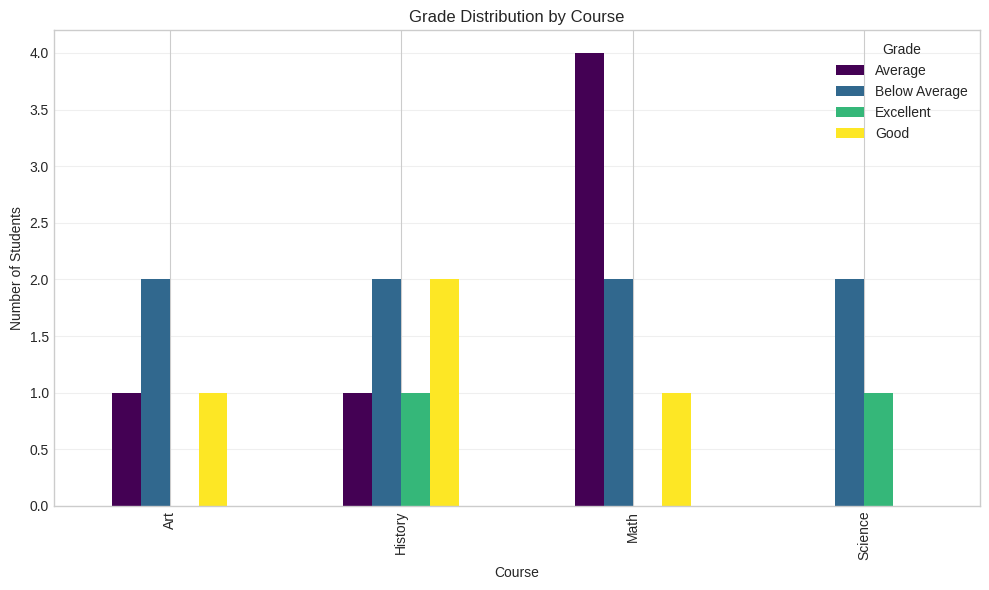

In [ ]:
# 5. Advanced Data Analysis (2 points)
# a. Use pandas functions to group and analyze the data by course (1 point)
print("\n--- Advanced Data Analysis by Course ---")

# Create age groups
df['age_group'] = pd.cut(df['age'],
                         bins=[17, 20, 25, 30, 35],
                         labels=['18-20', '21-25', '26-30', '31-35'])

# Group data by course and grade category
course_grade_analysis = pd.crosstab(
    df['course'],
    df['grade_category_filled'],
    normalize='index'
) * 100

print("Grade distribution by course (%):")
print(course_grade_analysis.round(1))

# Group by course and age group for deeper analysis
age_course_analysis = df.groupby(['course', 'age_group']).agg({
    'student_id': 'count',
    'score_filled': ['mean', 'min', 'max']
}).round(1)

print("\nScore analysis by course and age group:")
print(age_course_analysis)

# Correlation analysis
correlation = df[['age', 'score_filled']].corr()
print("\nCorrelation between age and score:")
print(correlation)


# b. Create visualizations that show the distribution of scores across different courses (1 point)
print("\n--- Creating Score Distribution Visualizations ---")

# Visualization 1: Box plot by course
plt.figure(figsize=(10, 6))
sns.boxplot(x='course', y='score_filled', data=df)
plt.title('Score Distribution by Course')
plt.xlabel('Course')
plt.ylabel('Score')
plt.grid(axis='y', alpha=0.3)
plt.savefig('score_distribution_by_course.png')
plt.show()

# Visualization 2: Grade distribution by course
grade_counts = pd.crosstab(df['course'], df['grade_category_filled'])
grade_counts.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Grade Distribution by Course')
plt.xlabel('Course')
plt.ylabel('Number of Students')
plt.legend(title='Grade')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('grade_distribution_by_course.png')
plt.show()